In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

## Dataset Columns Description

- **#**: ID for each Pokémon.
- **Name**: Name of each Pokémon.
- **Type 1**: Primary type of the Pokémon, which determines its weaknesses and resistances to attacks.
- **Type 2**: Secondary type of the Pokémon (if applicable). Some Pokémon have dual types.
- **Total**: Sum of all the base stats, providing a general indication of a Pokémon's overall strength.
- **HP**: Hit Points (Health). Determines how much damage a Pokémon can take before fainting.
- **Attack**: Base modifier for physical attacks (e.g., Scratch, Punch).
- **Defense**: Base resistance against physical attacks.
- **SP Atk**: Special Attack. Base modifier for special attacks (e.g., Fire Blast, Bubble Beam).
- **SP Def**: Special Defense. Base resistance against special attacks.
- **Speed**: Determines which Pokémon attacks first in a battle round.

In [29]:
df = pd.read_csv('pokemon.csv')
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [30]:
df.shape

(800, 13)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [32]:
df.nunique()

#             721
Name          800
Type 1         18
Type 2         18
Total         200
HP             94
Attack        111
Defense       103
Sp. Atk       105
Sp. Def        92
Speed         108
Generation      6
Legendary       2
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [40]:
# Null value summary
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Ratio (%)': (df.isnull().sum() / len(df)) * 100
})

print(null_summary.sort_values(by='Null Ratio (%)', ascending=False))

            Null Count  Null Ratio (%)
Type 2             386           48.25
#                    0            0.00
Name                 0            0.00
Type 1               0            0.00
Total                0            0.00
HP                   0            0.00
Attack               0            0.00
Defense              0            0.00
Sp. Atk              0            0.00
Sp. Def              0            0.00
Speed                0            0.00
Generation           0            0.00
Legendary            0            0.00


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
#,800.0,362.81375,208.343798,1.0,184.75,364.5,539.25,721.0
Total,800.0,435.10250,119.963040,180.0,330.00,450.0,515.00,780.0
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.00,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.00,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.00,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.00,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.00,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.00,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.00,6.0


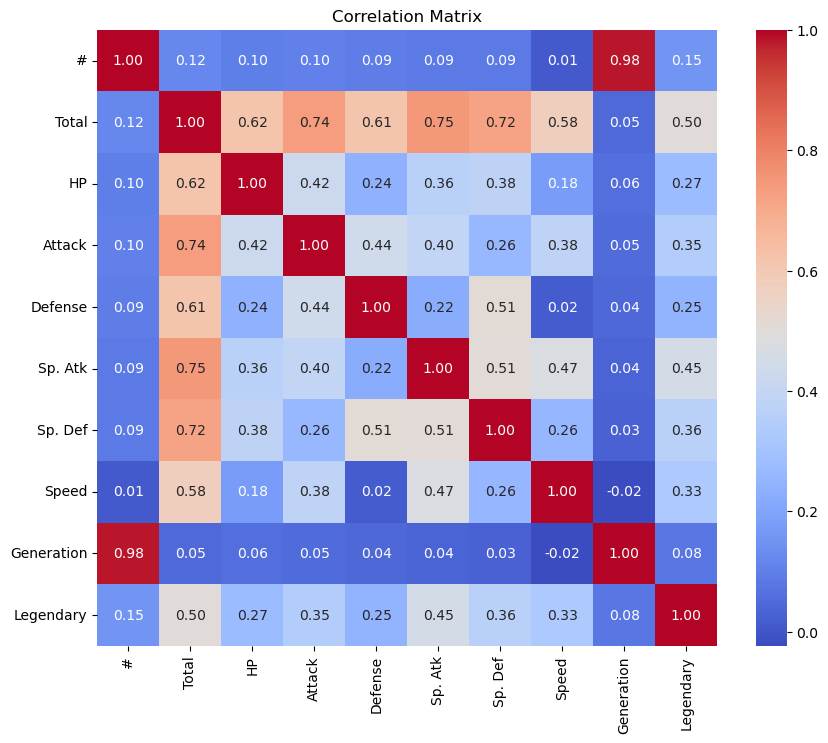

In [42]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Insights of Initial Analysis

- The dataset has 800 unique Pokemon and 13 features.
- Three of them are of object data type, one of them is bool and the rest (9) are integer data type.
- There is not any duplicated data in our dataset.
- Only one column has missing data, which is Type 2, and nearly half are missing.
- This is a very likely. Because some Pokemon' have only one type.
- Bulbasaur is a good illustration of having dual type, which are Grass and Poison. Charmander, on the other hand, is a good example of having single type (Fire).
- According to descriptive statistical analysis, some variables such as "HP, Special_Attack..." may have an outlier data. Also, the minimum values are thought-provoking.
- Since these are the actual values of the Pokemon, they will not be considered as outliers.
- To clarify things, let's look at the Pokemon with the highest Special Attack. Hold your hat — Indeed, this Pokemon is none other than Mega Mewtwo Y.

## Correlation Matrix:
- All correlations except Speed-Generation have positive relationship.
- "Total" has a positive and strong correlation with almost all other numerical columns, which makes perfect sense. Due to fact that if a Pokemon's abilities are high then that Pokemon Total will also be high.

| index | id | name | type_1 | type_2 | total | hp | attack | defense | special_attack | special_defense | speed | generation | legendary |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 164 | 150 | MewtwoMega Mewtwo Y | Psychic | NaN | 780 | 106 | 150 | 70 | 194 | 120 | 140 | 1 | true |

### Data Cleaning and Reduction

In [43]:

df.rename(columns={'#':'ID',
                   'Sp. Atk': 'Special Attack',
                   'Sp. Def': 'Special Defense'}, inplace=True)

df.columns = [x.replace(" ", "_").lower() for x in df.columns]

In [45]:
df['type_2'] = df['type_2'].replace(np.nan, "No_2nd_Type")

In [46]:
df.drop(['id'], axis=1, inplace=True)

In [47]:
df.head()

,name,type_1,type_2,total,hp,attack,defense,special_attack,special_defense,speed,generation,legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,No_2nd_Type,309,39,52,43,60,50,65,1,False


### Feature Extraction
- In this section we will create new features.
  - **is_dual_type**: This feature indicates whether a Pokémon has a valid Type 2.
  - **average_total**: This feature was created by dividing (averaging) the "Total" variable by six.
  - **full_type**: Combination of Type 1 and Type 2.

**Note:**

Total = HP + Attack + Defense + Special_Attack + Special_Defense + Speed

Average_Total = Total / 6

In [48]:
df['is_dual_type'] = df['type_2'].apply(lambda x: '0' if x=='No_2nd_Type' else '1')

In [49]:
df['full_type'] = df['type_1'] + " - " + df['type_2']

In [50]:
df.head()

,name,type_1,type_2,total,hp,attack,defense,special_attack,special_defense,speed,generation,legendary,is_dual_type,full_type
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,1,Grass - Poison
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,1,Grass - Poison
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,1,Grass - Poison
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,1,Grass - Poison
4,Charmander,Fire,No_2nd_Type,309,39,52,43,60,50,65,1,False,0,Fire - No_2nd_Type


### Minumum and Maximum Skilled Pokemons

In [51]:
skills = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']

max_skills_id = []
min_skills_id = []

for skill in skills:
  max_skills_id.append(df.loc[df[skill].idxmax()].name)
  min_skills_id.append(df.loc[df[skill].idxmin()].name)


df.iloc[min_skills_id,:].drop_duplicates().style.highlight_min(subset=skills, color = 'red')
     

,name,type_1,type_2,total,hp,attack,defense,special_attack,special_defense,speed,generation,legendary,is_dual_type,full_type
316,Shedinja,Bug,Ghost,236,1,90,45,30,30,40,3,False,1,Bug - Ghost
121,Chansey,Normal,No_2nd_Type,450,250,5,5,35,105,50,1,False,0,Normal - No_2nd_Type
230,Shuckle,Bug,Rock,505,20,10,230,10,230,5,2,False,1,Bug - Rock
13,Caterpie,Bug,No_2nd_Type,195,45,30,35,20,20,45,1,False,0,Bug - No_2nd_Type


In [52]:
df.iloc[max_skills_id,:].style.highlight_max(subset=skills, color = 'lightgreen')

,name,type_1,type_2,total,hp,attack,defense,special_attack,special_defense,speed,generation,legendary,is_dual_type,full_type
261,Blissey,Normal,No_2nd_Type,540,255,10,10,75,135,55,2,False,0,Normal - No_2nd_Type
163,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,1,Psychic - Fighting
224,SteelixMega Steelix,Steel,Ground,610,75,125,230,55,95,30,2,False,1,Steel - Ground
164,MewtwoMega Mewtwo Y,Psychic,No_2nd_Type,780,106,150,70,194,120,140,1,True,0,Psychic - No_2nd_Type
230,Shuckle,Bug,Rock,505,20,10,230,10,230,5,2,False,1,Bug - Rock
431,DeoxysSpeed Forme,Psychic,No_2nd_Type,600,50,95,90,95,90,180,3,True,0,Psychic - No_2nd_Type


### Average Scores for each Generation

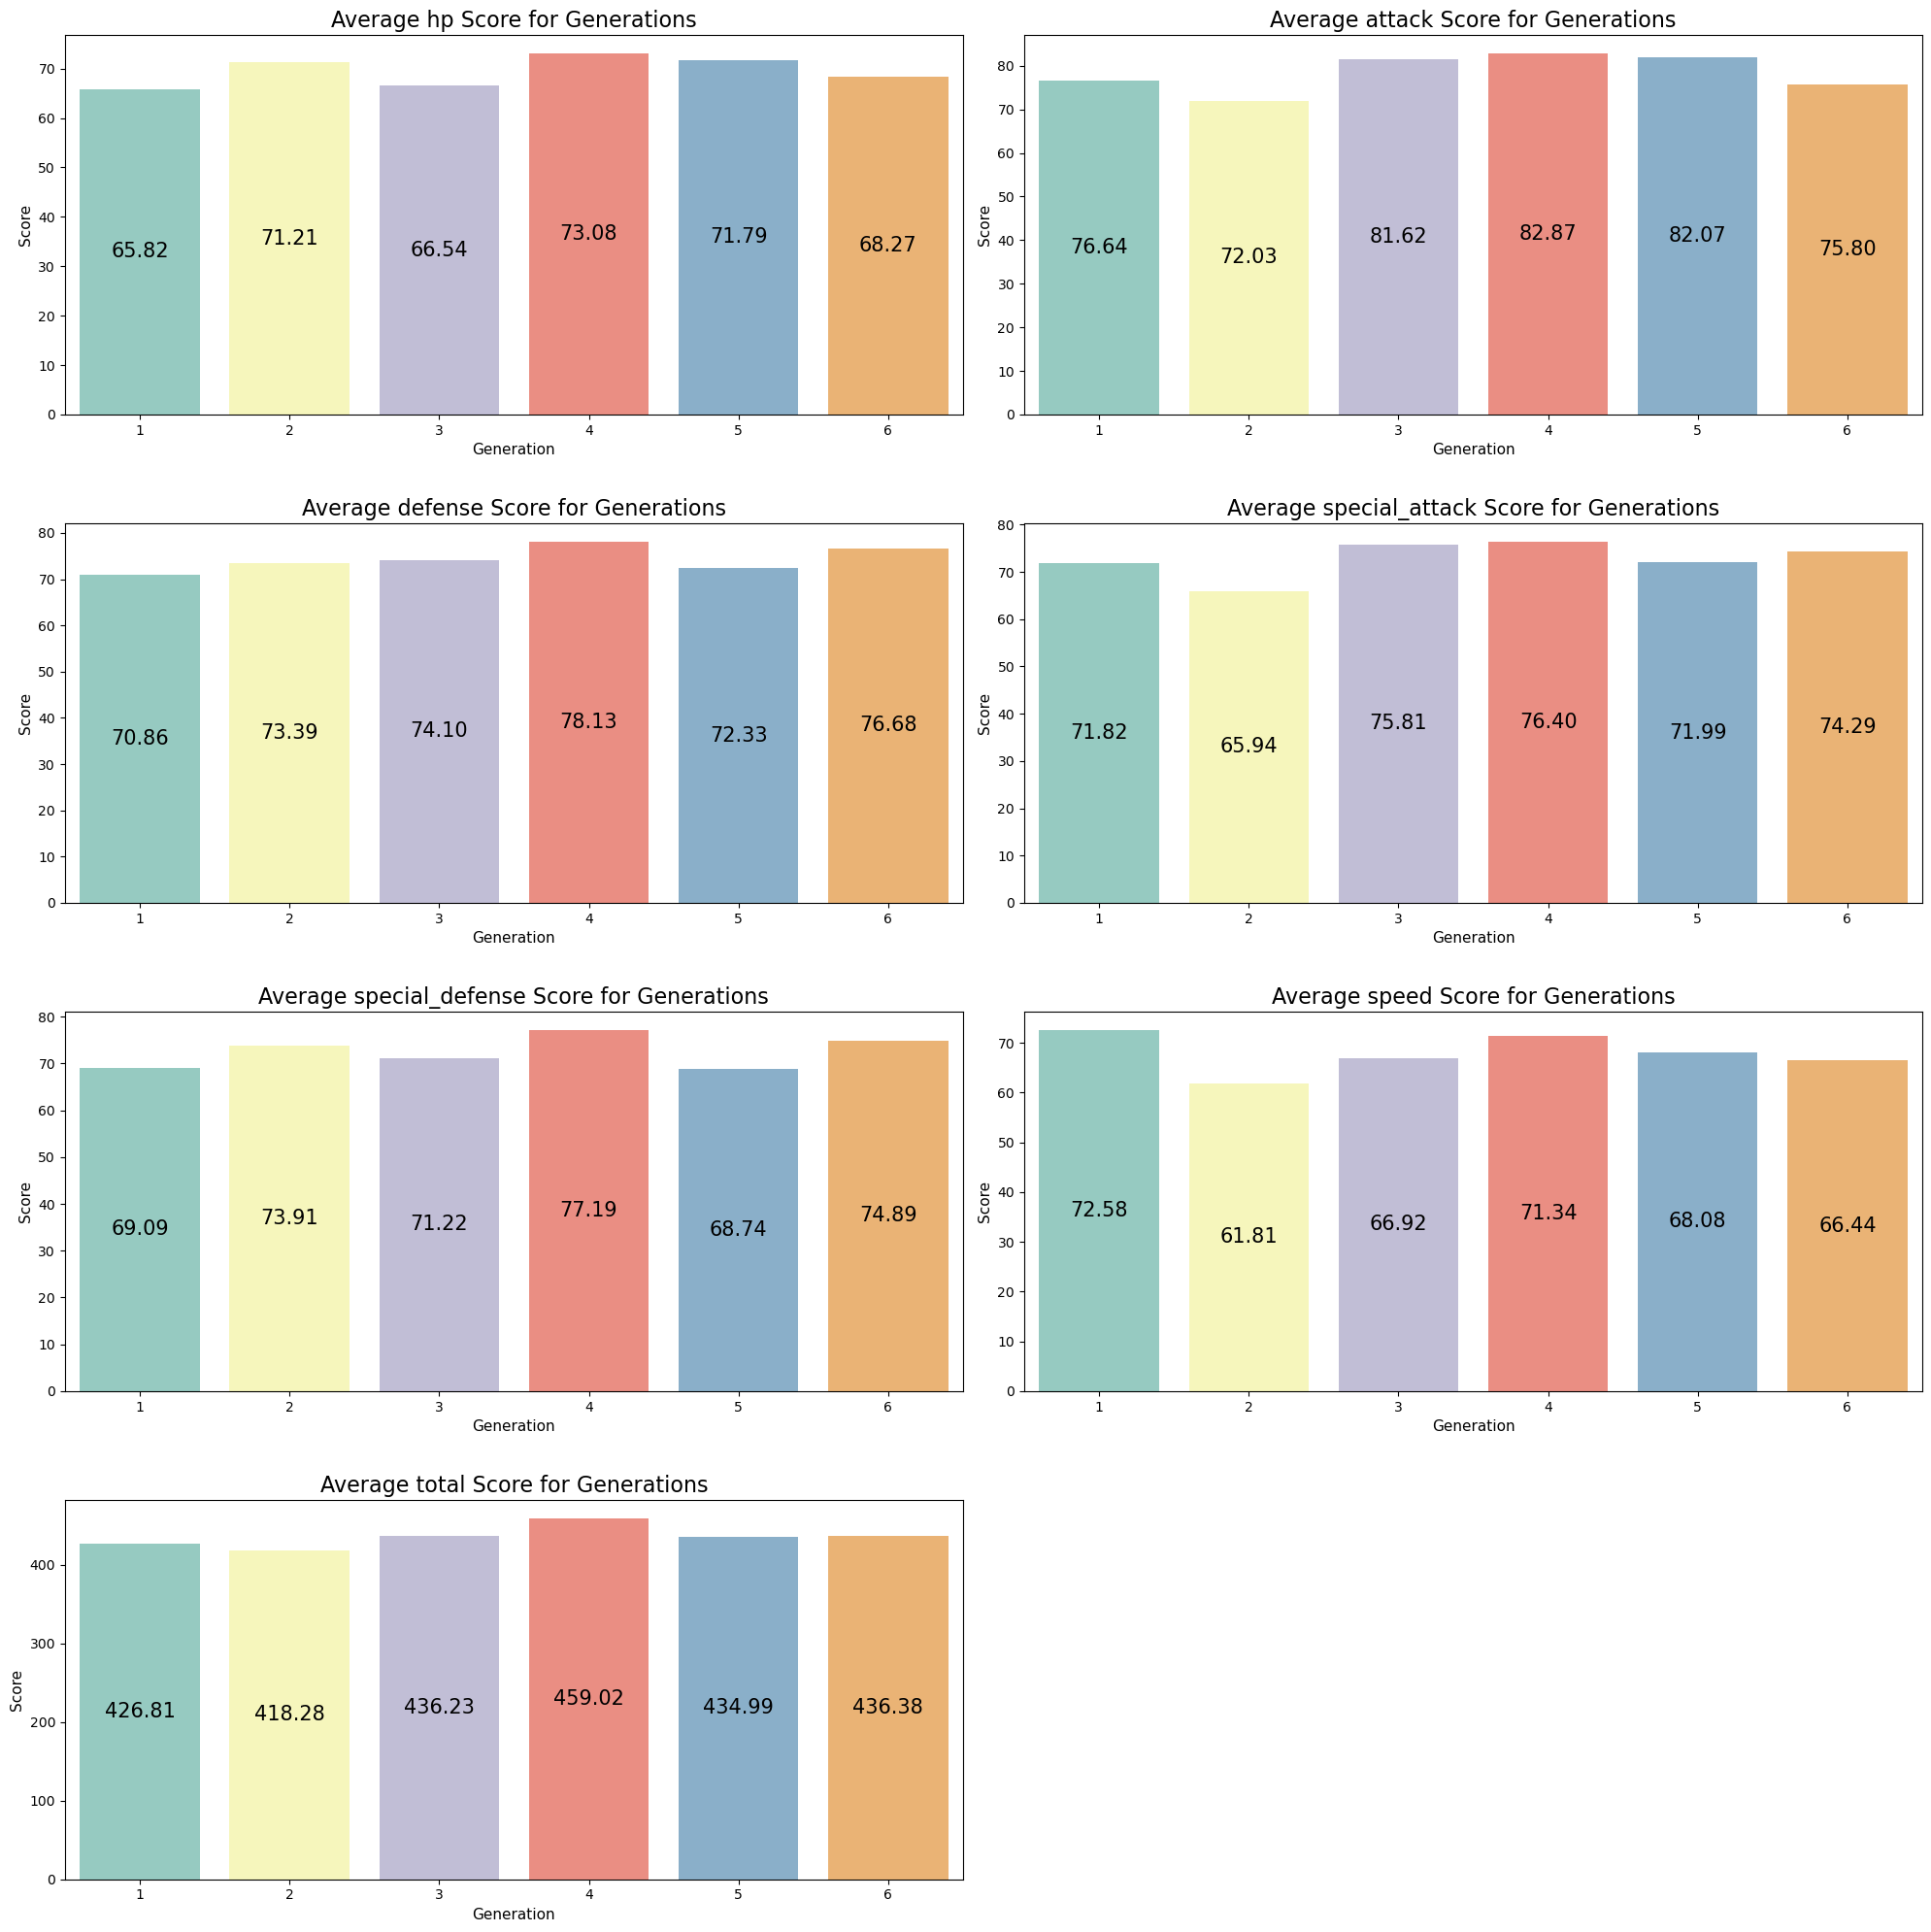

In [53]:
skills = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'total']

n_cols = 2
n_rows = (len(skills) - 1) // n_cols + 1

fig, axs = plt.subplots(n_rows, n_cols, figsize = (20, 20))
axs = axs.flatten()

for n, skill in enumerate(skills):
    ax = sns.barplot(x = df.groupby(['generation'])[skill].mean().index,
                     y = df.groupby(['generation'])[skill].mean().values,
                     ax=axs[n],
                     palette='Set3')

    axs[n].set_title(f"Average {skill} Score for Generations", fontsize=16)
    axs[n].set_xlabel("Generation", fontsize=11)
    ax.set_ylabel(f'Score', fontsize=11)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=15, label_type='center')

    if not axs.flat[-1].lines:
        axs.flat[-1].set_visible(False)

plt.tight_layout(h_pad=3)
plt.show()

### Skill Distributions

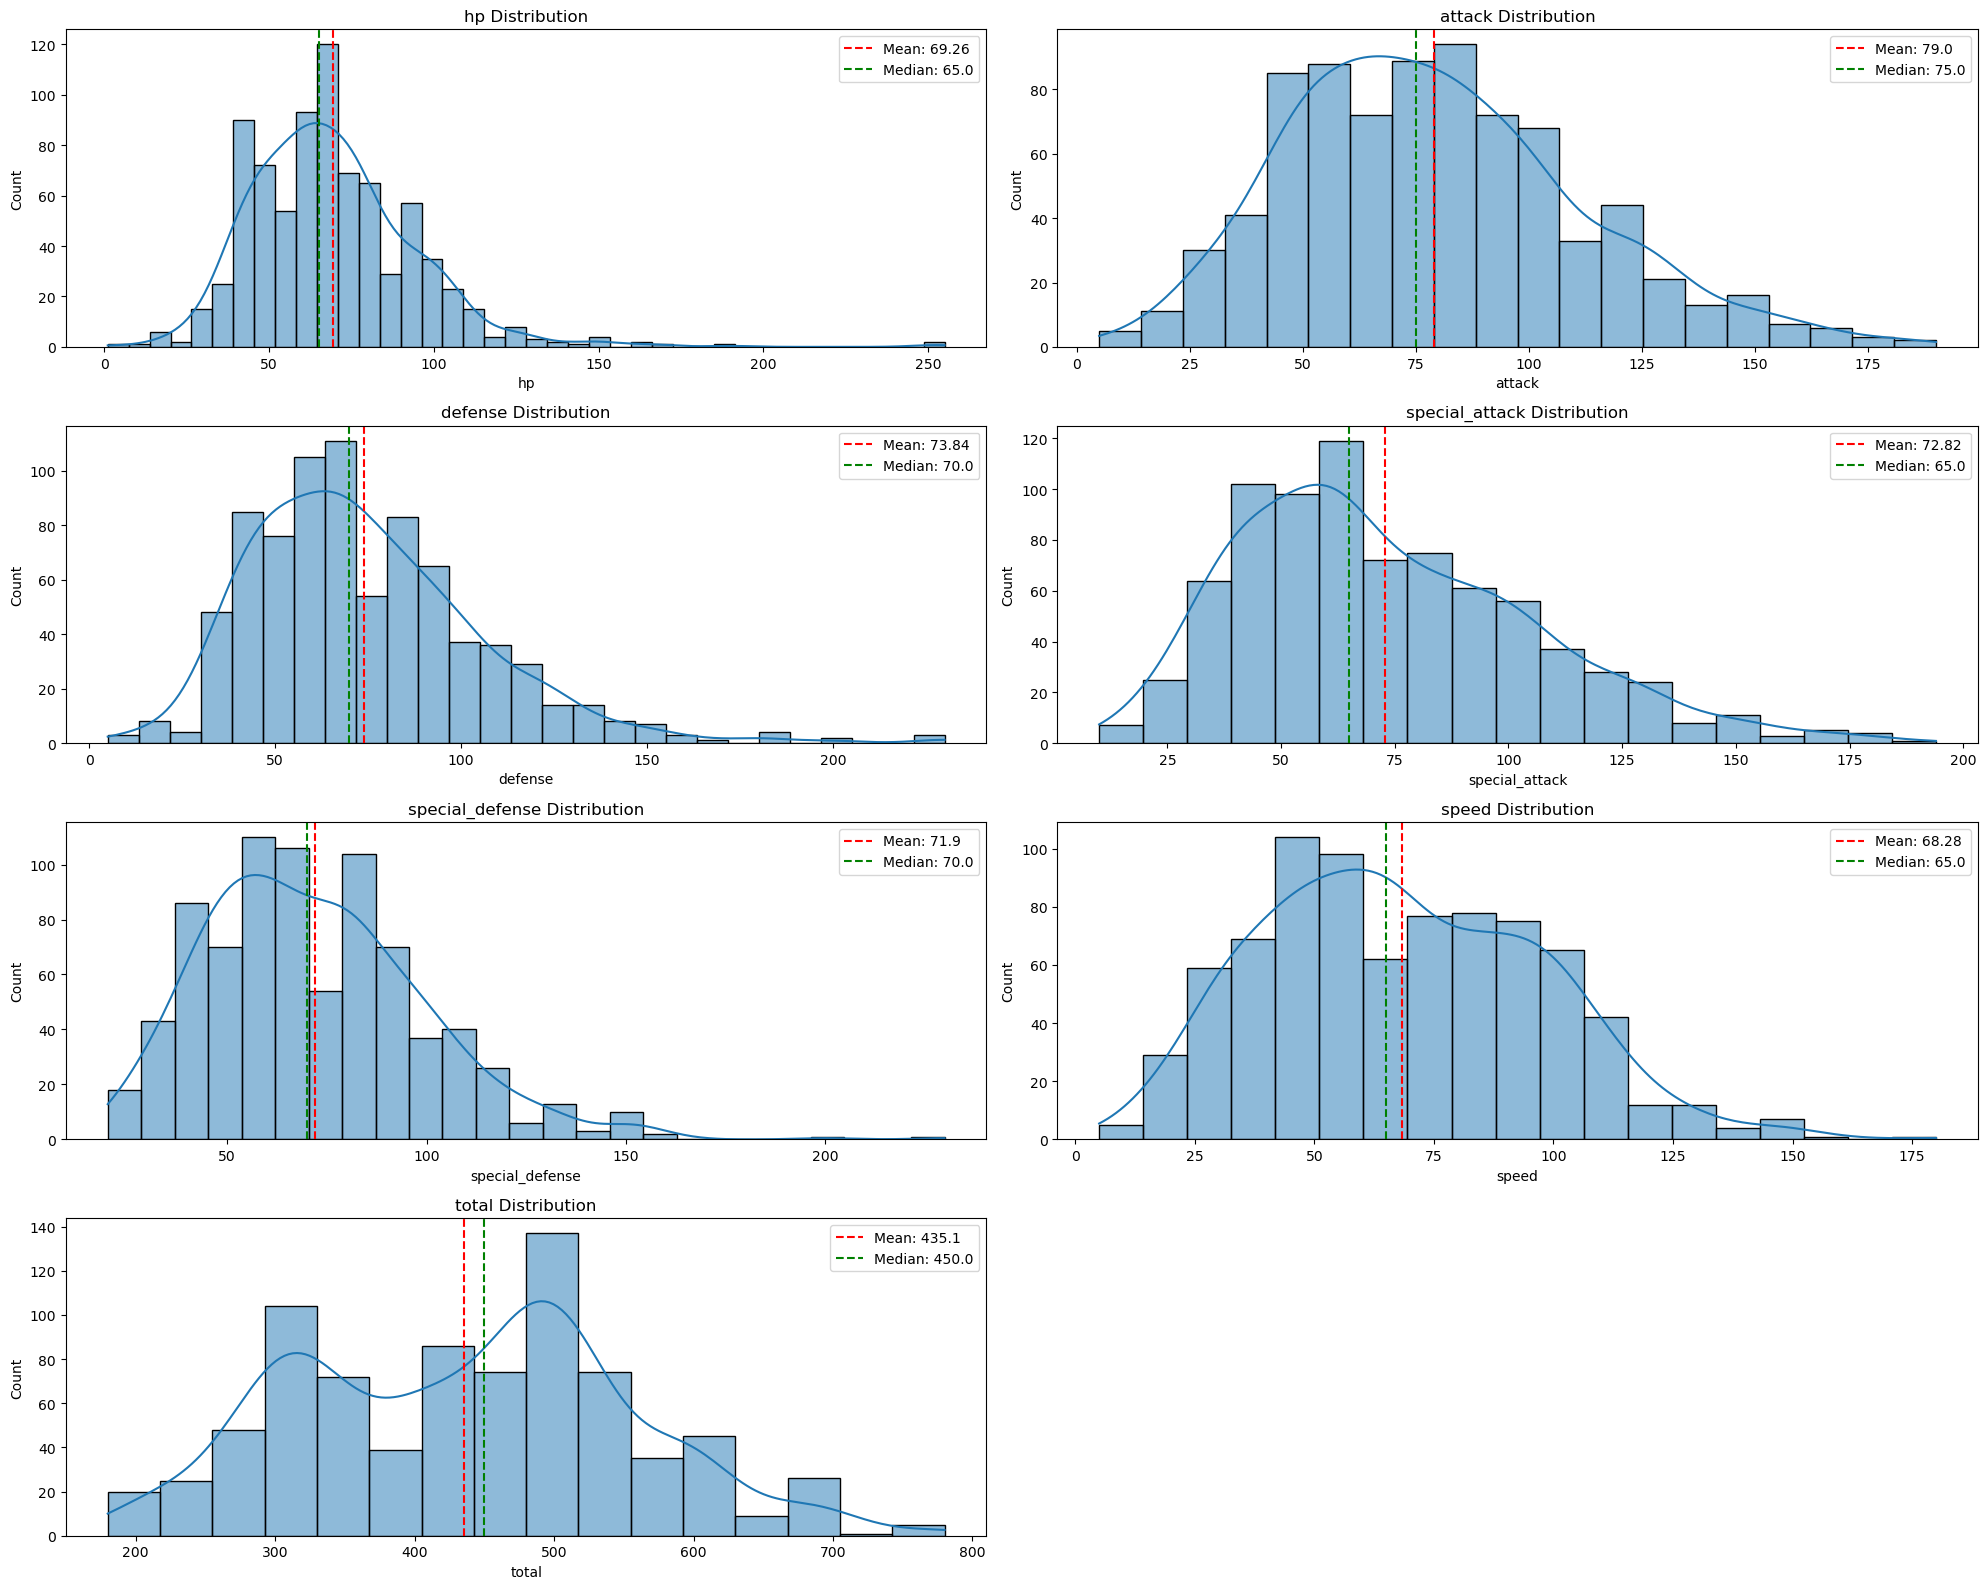

In [54]:
def plot_histogram(dataframe, features, n_cols, statistic=False):
    n_rows = (len(features) - 1) // n_cols + 1

    fig, axs = plt.subplots(n_rows, n_cols, figsize = (20, 16))
    axs = axs.flatten()

    for n, feature in enumerate(features):
        ax = sns.histplot(dataframe[feature],
                          kde=True,
                          ax=axs[n])
        if statistic:
            ax.axvline(np.mean(dataframe[feature]), ls='--', c='r',
                       label=f"Mean: {np.mean(dataframe[feature]).round(2)}")
            ax.axvline(np.median(dataframe[feature]), ls='--', c='g',
                       label=f"Median: {np.median(dataframe[feature]).round(2)}")
            ax.legend()
        ax.set_title(f'{feature} Distribution')

    if not axs.flat[-1].lines:
        axs.flat[-1].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_histogram(df, skills, 2, True)
     

### Pie Chart of Legendary Pokemon

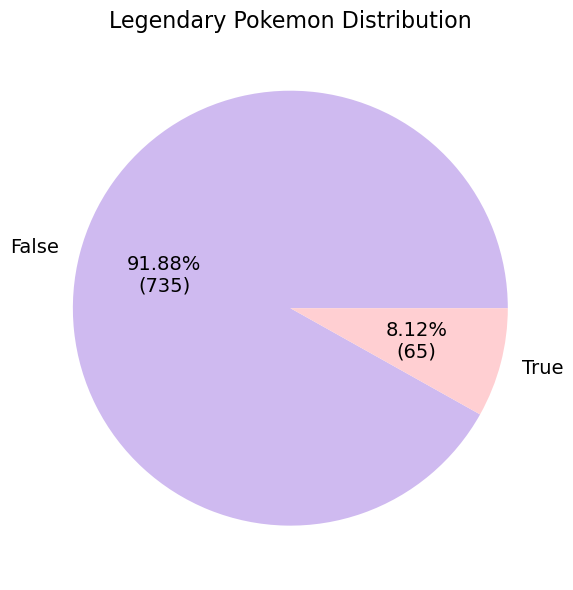

In [55]:
def plot_pie(dataframe, feature, title, colors=None, pct=True):
    fig,  axs = plt.subplots(1,1, figsize = (15, 6))

    def custom_pct(pct, allvals):
        absolute = int(np.round(pct/100.*np.sum(allvals)))
        return f"{pct:.2f}%\n({absolute:d})"

    dataframe[feature].value_counts().plot.pie(autopct=lambda pct: custom_pct(pct, dataframe[feature].value_counts()),
                                               ylabel='',
                                               colors = colors,
                                               textprops=dict(color="black", size=14));
    plt.title(title,fontsize=16)
    plt.tight_layout()
    plt.show()

plot_pie(df, 'legendary', 'Legendary Pokemon Distribution', ["#cfbaf0", "#ffcfd2"])
     

### Pie Chart of Generation

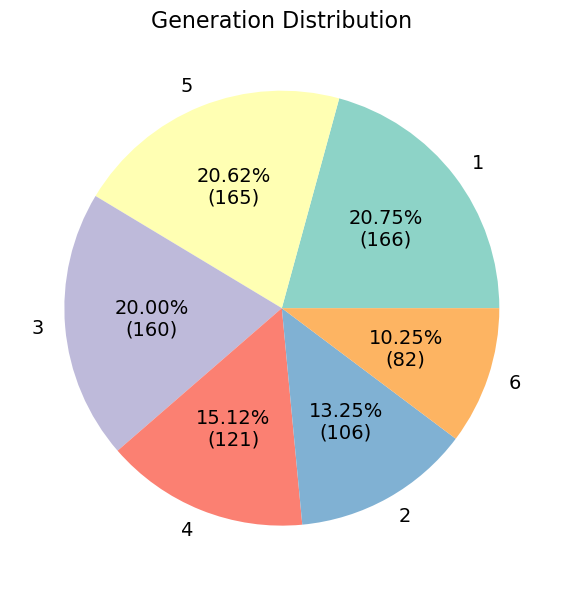

In [57]:
plot_pie(df, 'generation', 'Generation Distribution', colors=sns.color_palette('Set3'))

### Pokemon Stats

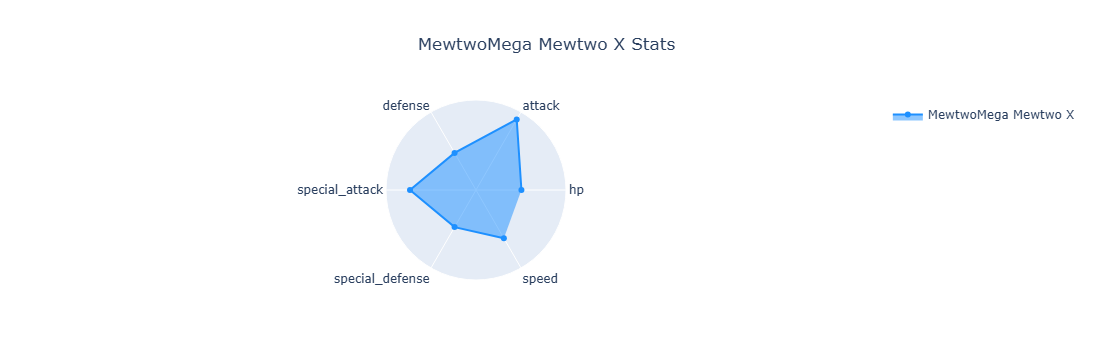

In [60]:
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go

skills = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']

def pokemon_stats(name):
    x = df[df["name"] == name]

    data = go.Scatterpolar(r = df.loc[x.index[0], skills].values,
                           theta = skills,
                           fill = 'toself',
                           line =  dict(color = 'dodgerblue'),
                           name = name)

    layout = go.Layout(polar = dict(radialaxis = dict(visible = False,
                                                      range = [0, x[skills].max().max()+20])),
                       showlegend = True,
                       title = f"{name} Stats",
                       title_x = 0.5)

    fig = go.Figure(data=data, layout=layout)
    iplot(fig, filename = "Two Pokemon stats")

pokemon_stats("MewtwoMega Mewtwo X")

### Comparing Two Pokemon Stats

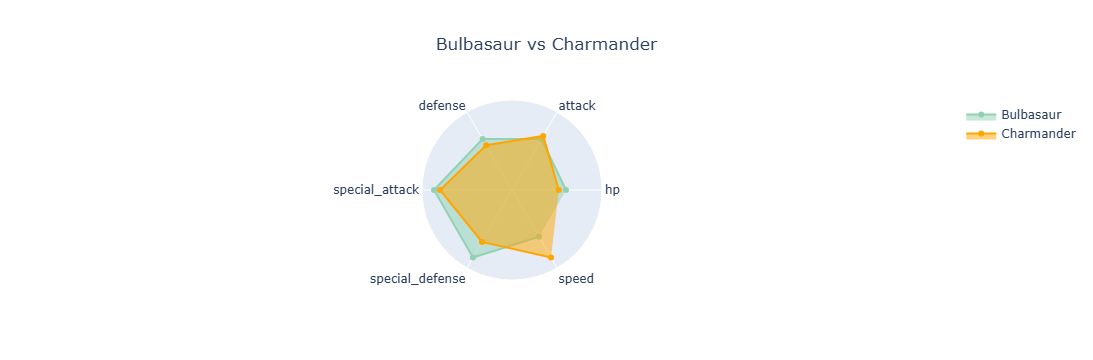

In [61]:
skills = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']

def compare_pokemons(first_name, second_name):
    x = df[df["name"] == first_name]
    y = df[df["name"] == second_name]

    trace0 = go.Scatterpolar(r = df.loc[x.index[0], skills].values,
                             theta = skills,
                             fill = 'toself',
                             line =  dict(color = '#92D1B3'),
                             name = first_name)

    trace1 = go.Scatterpolar(r = df.loc[y.index[0], skills].values,
                             theta = skills,
                             fill = 'toself',
                             line =  dict(color = 'orange'),
                             name = second_name)

    data = [trace0, trace1]

    layout = go.Layout(polar = dict(radialaxis = dict(visible = False,
                                                      range = [0, pd.concat([x,y])[skills].max().max()+10])),
                       showlegend = True,
                       title = f"{first_name} vs {second_name}",
                       title_x = 0.5)

    fig = go.Figure(data=data, layout=layout)
    iplot(fig, filename = "Two Pokemon stats")

compare_pokemons("Bulbasaur", "Charmander")

### Type 1 and Type 2 Heatmap

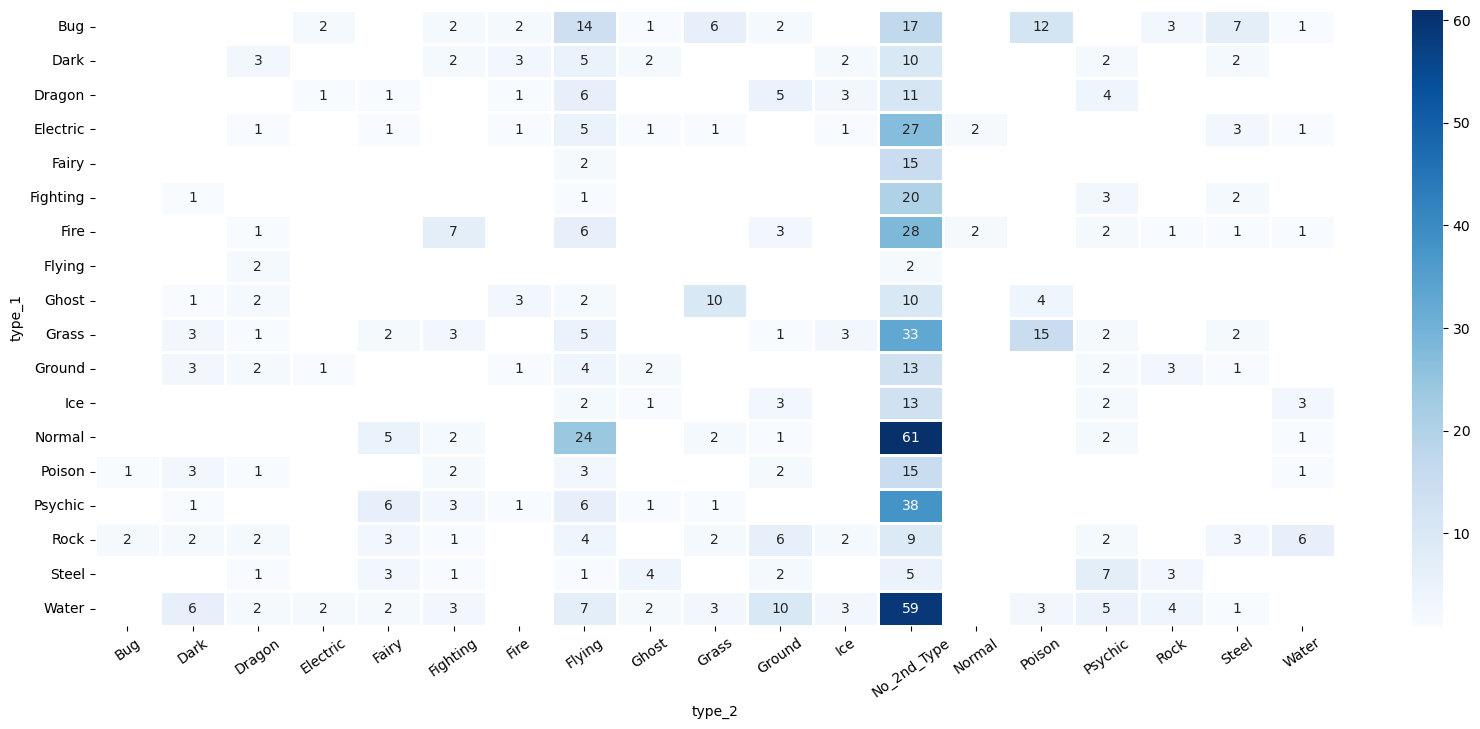

In [62]:
plt.subplots(figsize=(20, 8))

sns.heatmap(df.groupby(['type_1', 'type_2']).size().unstack(),
            linewidths=1,
            annot=True,
            cmap="Blues")

plt.xticks(rotation=35)
plt.show()

### Pairplot

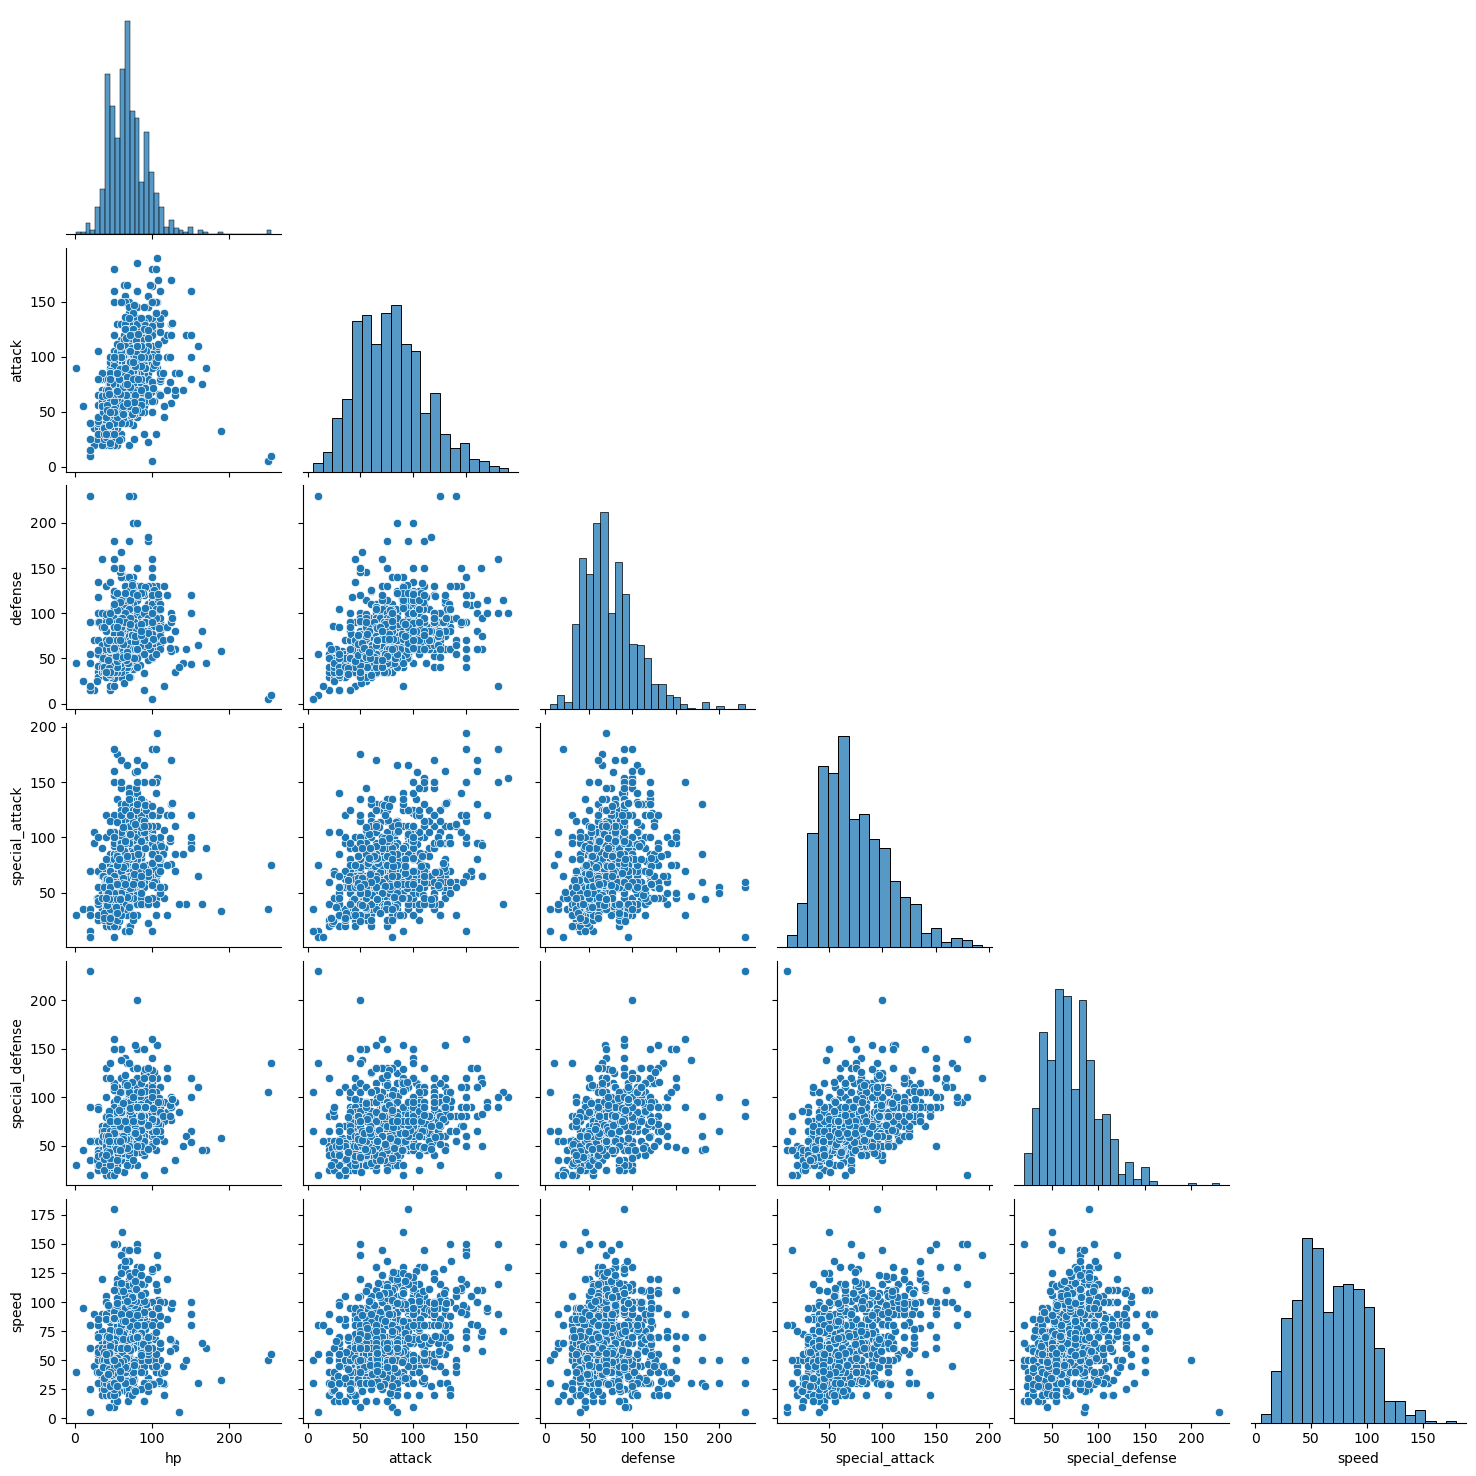

In [63]:
sns.pairplot(data=df, vars=skills, corner=True);

### Correlation Matrix

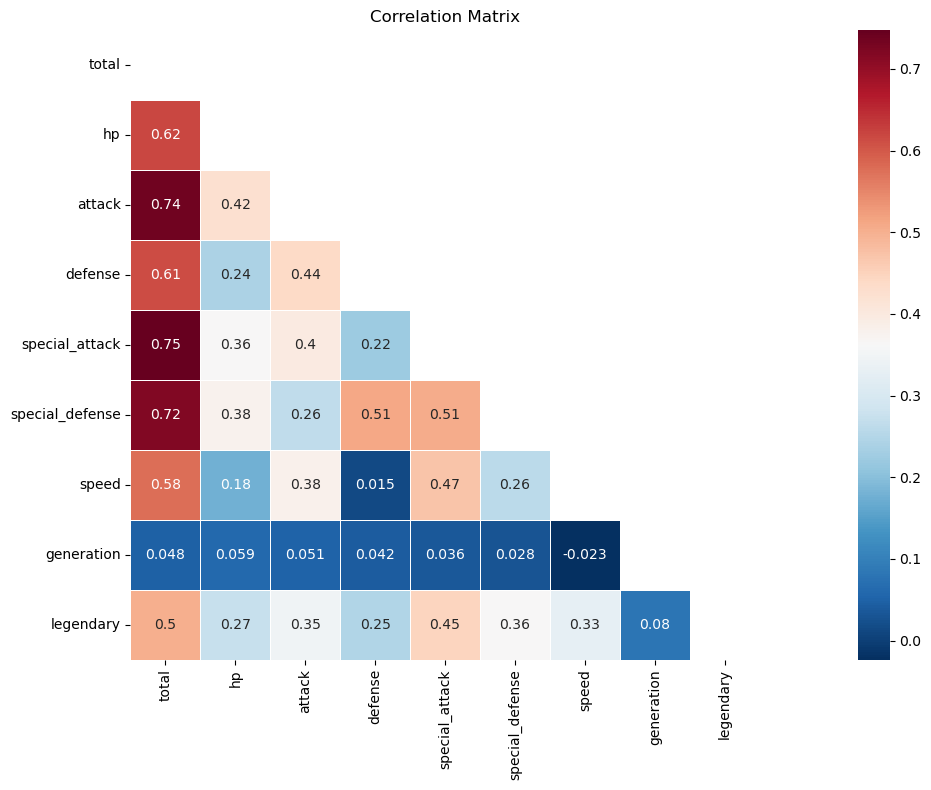

In [64]:
plt.figure(figsize=(20,8))
corr_mx = df.corr(numeric_only=True)
mask = np.triu(corr_mx)
sns.heatmap(corr_mx,
            linewidths=0.5,
            square=True,
            cmap="RdBu_r",
            mask=mask,
            annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()

# Project Conclusion
- The project mainly focused on Exploratory Data Analysis. For this, Pandas, Matplotlib, Seaborn and Plotly were frequently used.

#### Key Takeaways & Insights

- Missing values were not filled with any "Type" values. Instead these missing values are replaced with a string.
- Since the values are the actual values of the Pokemon, no action will be taken for outliers in this set.
- The "Total" variable is highly correlated with the stat variables (HP, Defense, Attack, Special Attack, Special Defense, Speed). Because "Total" is derived from the sum of these 6 variables.
- The distribution of the "Legendary" variable is unbalanced.
- The "Generation" variable has a slightly unbalanced distribution, although not as much as "Legendary".